<a href="https://colab.research.google.com/github/lapshinaaa/recsys-tasks/blob/main/DeepRecSys3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep RecSys Course
## Neural Ranking №3

In this task, we'll explore the methods of encoding categorical and numerical features, and then train a multi-task neural ranking model based on DCN V2 with mixture of experts.

Our model will be solving two problems in parallel:
- prediction of listening to a track;
- prediction of a like to a track.

# 1. Dataset Preparation

## yambda-50m-lag-features

We will use a dataset with precomputed Yambda features.

How this dataset was constructed:

1. The Yambda dataset `flat/50m multi_event` was taken as the base.
2. Only non-organic events were retained, that is, events obtained from recommendation surfaces, for example from My Wave in Yandex Music.
3. `is_skip = True` if the user listened to less than half of the track.
4. `is_full_play = True` if the user listened to more than 95% of the track.
5. In Yambda, a like and a listen are different events. At the same time, the model is trained on listening events: features are computed specifically for them, and the model must predict targets specifically for them. Therefore, likes must be attributed to listens, that is, we need to determine which exact listen each like belongs to. For this, each like is attached to the nearest-in-time listen of the same `(uid, item_id)` within 24 hours. If there are two suitable listens, the nearest one is chosen; in case of a tie, the previous one is chosen. After that, `is_like = True` for a listen if at least one like was attached to it.
6. After that, real-valued counters are computed over the dataset. They are divided into three types: user counters, track counters, and cross-counters. Importantly, for each listen with `timestamp`, all counters are computed not at the moment of the event itself, but at the moment `timestamp - lag_seconds`, where `lag_seconds = 15 minutes`. This delay is needed to prevent leakage during training and evaluation. The idea is that when making a prediction for the current listen, the model must not use information that appeared only after this event or too close to it and would not yet have had time to reach the features in a real system. This is especially important in our setup because later quality will be evaluated on temporally adjacent listens. This means that when comparing the current track with the previous one, we must not allow the features of the current object to already contain feedback on the previous track that should not yet have been available at prediction time. Otherwise, the model would effectively be peeking at the answer, and quality would be overestimated. In addition, such a lag better matches how features are usually updated in real recommendation systems: not instantly, but with some delay.
7. `is_like` and `is_full_play` are used as targets in the multi-task learning setup.

The dataset construction code can be viewed here: https://huggingface.co/datasets/matfu21/yambda-50m-lag-features/blob/main/event_processor.py#L296

In [2]:
import warnings
warnings.filterwarnings("ignore")

import gc
import polars as pl
import tests
from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id="matfu21/yambda-50m-lag-features",
    repo_type="dataset",
    filename="listens.parquet",
)
listens = pl.read_parquet(path)

## Keep only preference-bearing pairs

In ranking tasks, the model is usually trained not on all events indiscriminately, but on specially selected objects that carry a signal about user preferences. This is especially important for relatively small ranking models. If such a model is trained on all examples in sequence, it will tend to learn global probabilities of like or full play more than it learns to correctly order temporally close objects. As a result, quality on the local pairwise comparisons that we actually care about may deteriorate. Therefore, in practice, training datasets for ranking are often sampled so as to retain only examples with useful feedback.

At the same time, it is important to understand that this is more of an engineering compromise than a fundamental limitation. If we had very large models with high expressive power and no strict computational constraints, then ideally we really would want to learn from all available events. Such a model could simultaneously recover global patterns well and also model local preferences with high quality. But in real recommendation systems, ranking models usually remain relatively compact, so it is useful to help them focus specifically on the examples that matter most for ranking.

Why ranking models are usually relatively small: such models operate at the final ranking stage, where it is necessary to recompute scores very quickly for a large number of candidates. The system typically has strict constraints on latency, memory, and queries per second. Therefore, it is difficult to use overly large models here: they would be too expensive and too slow in production. Precisely because of this, it is especially important that a small or medium-sized model spend its expressive capacity on genuinely useful examples rather than on predicting averaged global probabilities.

In this assignment, you need to keep only those listening events that belong to at least one local pair with differing feedback. The idea is as follows: if the current track and the temporally adjacent track have different signals, then such a pair helps train ranking. But if both on the left and on the right the feedback is the same, then the current event is less useful for this setup.

### What needs to be done

For each event, you need to:
1. look at the previous event of the same user;
2. look at the next event of the same user;
3. check whether `is_like` or `is_full_play` differs on at least one side;
4. keep only those rows for which such a difference exists.

### Important detail about sorting

Before looking at neighboring events, the data must be sorted by:
- `uid`,
- `timestamp`,
- `row_id`.

The `row_id` field is needed for determinism. The same user may have events with identical `timestamp`, and in that case sorting only by `uid` and `timestamp` does not define a unique order. Adding `row_id` makes that order fixed and reproducible.

In [3]:
def extract_preference_pairs(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .with_row_index("row_id")
        .sort(["uid", "timestamp", "row_id"])
        .with_columns([
            pl.col("is_like").shift(1).over("uid").alias("prev_is_like"),
            pl.col("is_like").shift(-1).over("uid").alias("next_is_like"),
            pl.col("is_full_play").shift(1).over("uid").alias("prev_is_full_play"),
            pl.col("is_full_play").shift(-1).over("uid").alias("next_is_full_play"),
        ])
        .with_columns([
            (
                ((pl.col("is_like") != pl.col("prev_is_like")) |
                 (pl.col("is_full_play") != pl.col("prev_is_full_play")))
                & pl.col("prev_is_like").is_not_null()
            ).alias("diff_prev"),
            (
                ((pl.col("is_like") != pl.col("next_is_like")) |
                 (pl.col("is_full_play") != pl.col("next_is_full_play")))
                & pl.col("next_is_like").is_not_null()
            ).alias("diff_next"),
        ])
        .filter(pl.col("diff_prev") | pl.col("diff_next"))
        .drop([
            "prev_is_like",
            "next_is_like",
            "prev_is_full_play",
            "next_is_full_play",
            "diff_prev",
            "diff_next",
            "row_id",
        ])
    )

listens = extract_preference_pairs(listens)
tests.test_extract_preference_pairs(listens)

All good! :)


In [4]:
listens.shape

(6885472, 23)

## The Yambda dataset

In this assignment, we will use the Yambda dataset: https://huggingface.co/datasets/yandex/yambda. From it, we will obtain information about the albums to which a track belongs, as well as about the artists of that track. These data will be needed to construct multivalent features.

Below is the class from Hugging Face that you will need to use.

In [5]:
from dataclasses import dataclass


@dataclass
class DatasetConfig:
    dataset_type: str = 'flat'
    dataset_size: str = '50m'
    interaction_name: str = 'multi_event'
    default_like_window_seconds: int = 24 * 60 * 60
    lag_seconds: int = 15 * 60

dataset_config = DatasetConfig()

In [6]:
from typing import Literal
from datasets import Dataset, DatasetDict, load_dataset


# YambdaDataset wrapper class (https://huggingface.co/datasets/yandex/yambda)
class YambdaDataset:
    INTERACTIONS = frozenset([
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ])

    def __init__(
        self,
        dataset_type: Literal["flat", "sequential"] = "flat",
        dataset_size: Literal["50m", "500m", "5b"] = "50m"
    ):
        assert dataset_type in {"flat", "sequential"}
        assert dataset_size in {"50m", "500m", "5b"}
        self.dataset_type = dataset_type
        self.dataset_size = dataset_size

    def interaction(self, event_type: Literal[
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ]) -> Dataset:
        assert event_type in YambdaDataset.INTERACTIONS
        return self._download(f"{self.dataset_type}/{self.dataset_size}", event_type)

    def audio_embeddings(self) -> Dataset:
        return self._download("", "embeddings")

    def album_item_mapping(self) -> Dataset:
        return self._download("", "album_item_mapping")

    def artist_item_mapping(self) -> Dataset:
        return self._download("", "artist_item_mapping")

    @staticmethod
    def _download(data_dir: str, file: str) -> Dataset:
        data = load_dataset("yandex/yambda", data_dir=data_dir, data_files=f"{file}.parquet")
        # Returns DatasetDict; extracting the only split
        assert isinstance(data, DatasetDict)
        return data["train"]


In [7]:
yambda_dataset = YambdaDataset(
    dataset_type=dataset_config.dataset_type,
    dataset_size=dataset_config.dataset_size
)
albums = yambda_dataset.album_item_mapping().to_polars()
artists = yambda_dataset.artist_item_mapping().to_polars()

In [8]:
albums

album_id,item_id
u32,u32
1,1491131
1,5109849
1,6735246
2,2859065
3,1859377
…,…
3367688,7302579
3367688,8345353
3367689,269381


In [9]:
artists

artist_id,item_id
u32,u32
1,953587
1,1921481
1,2659068
1,2740764
1,6767564
…,…
1293390,8177055
1293391,8269848
1293392,5930302


In [10]:
listens

uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_full_play,is_skip,user_lag_listen_cnt,user_lag_like_cnt,user_lag_full_play_cnt,user_lag_skip_cnt,item_lag_listen_cnt,item_lag_like_cnt,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio
u32,u32,u32,u16,u32,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
100,40110,732449,100,240,false,true,false,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,50.5,0.0
100,40360,3397170,46,130,false,false,true,2.0,0.0,2.0,0.0,4.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,100.0,83.25,0.0
100,40380,7849270,100,205,false,true,false,2.0,0.0,2.0,0.0,7.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,100.0,57.428571,0.0
100,41130,6474571,100,245,false,true,false,4.0,0.0,4.0,0.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,100.0,7.0,0.0
100,41545,7847600,27,250,false,false,true,7.0,0.0,6.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,92.285714,100.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1000000,25277150,7479030,99,155,false,true,false,361.0,3.0,330.0,27.0,786.0,1.0,710.0,60.0,0.0,0.0,0.0,0.0,92.725762,92.410941,0.0
1000000,25277170,9295648,15,120,false,false,true,361.0,3.0,330.0,27.0,4686.0,4.0,3789.0,745.0,0.0,0.0,0.0,0.0,92.725762,84.593257,0.0
1000000,25960045,1914019,100,185,false,true,false,365.0,3.0,332.0,29.0,2505.0,47.0,1488.0,903.0,0.0,0.0,0.0,0.0,92.309589,65.346108,0.0


## Adding multivalent features

Earlier, we loaded the `albums` and `artists` data. Now, based on them, you need to add two new columns with multivalent categorical features to the table:
- `artist_ids` — the list of artists corresponding to the given track;
- `album_ids` — the list of albums corresponding to the given track.

Thus, for each track, these columns should store not a single identifier, but a list of identifiers.

So the logic is as follows

artists_agg:  item_id -> `[artist_id1, artist_id2, ...]`

albums_agg:   item_id -> `[album_id1, album_id2, ...]`

and then

listens + item_id -> artist_ids, album_ids

In [11]:
def join_item_artist_album(
    listens: pl.DataFrame,
    artists: pl.DataFrame,
    albums: pl.DataFrame,
) -> pl.DataFrame:
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################
    artists_agg = artists.group_by("item_id").agg(
    pl.col("artist_id").alias("artist_ids")
    )

    albums_agg = albums.group_by("item_id").agg(
        pl.col("album_id").alias("album_ids")
    )

    listens = (
        listens
        .join(artists_agg, on="item_id", how="left")
        .join(albums_agg, on="item_id", how="left")
    )

    return listens

listens = join_item_artist_album(listens, artists, albums)
tests.test_join_item_artist_album(listens)
del artists, albums
gc.collect()

All good! :)


0

In [12]:
listens.head(4)

uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_full_play,is_skip,user_lag_listen_cnt,user_lag_like_cnt,user_lag_full_play_cnt,user_lag_skip_cnt,item_lag_listen_cnt,item_lag_like_cnt,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio,artist_ids,album_ids
u32,u32,u32,u16,u32,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[u32],list[u32]
100,40110,732449,100,240,false,true,false,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,50.5,0.0,[94924],[1632076]
100,40360,3397170,46,130,false,false,true,2.0,0.0,2.0,0.0,4.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,100.0,83.25,0.0,[997338],[403561]
100,40380,7849270,100,205,false,true,false,2.0,0.0,2.0,0.0,7.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,100.0,57.428571,0.0,[995468],[477338]
100,41130,6474571,100,245,false,true,false,4.0,0.0,4.0,0.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,100.0,7.0,0.0,[163539],[1412710]


## Splitting the data into training and test sets

Next, you need to write a function that splits the dataset into two parts by time:
- `train` should contain all events except those from the last `test_last_seconds` seconds;
- `test` should contain events from the last `test_last_seconds` seconds, including the boundary.

In this assignment, we will use the last 30 days as the test set.

In [13]:
def temporal_train_test_split(
    df: pl.DataFrame,
    test_last_seconds: float,
    time_column: str = "timestamp",
) -> tuple[pl.DataFrame, pl.DataFrame]:
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################
    max_ts = df.select(pl.col(time_column).max()).item() # to split the data correctly
    split_ts = max_ts - test_last_seconds

    train = df.filter(pl.col(time_column) < split_ts)
    test = df.filter(pl.col(time_column) >= split_ts)

    return train, test

train_listens, test_listens = temporal_train_test_split(listens, test_last_seconds=30 * 24 * 60 * 60)
tests.test_temporal_train_test_split(train_listens, test_listens)
del listens
gc.collect()

All good! :)


0

# 2. Training and evaluating baselines

## Pairwise accuracy

The metric that will be used to evaluate the quality of your solution is called `pairwise accuracy`.

The idea of the metric is as follows: we want to check whether the model can correctly order temporally adjacent events of the same user. For example, if in a pair of neighboring tracks one received a like and the other did not, then the track with the like should receive a higher score.

The function takes as input:
- `uids` — user identifiers;
- `timestamps` — event times;
- `labels` — binary targets (`0` or `1`);
- `probs` — scores predicted by the model;
- `session_gap_seconds` — the maximum allowed time gap between neighboring events.

What needs to be implemented:
1. group events by users;
2. within each user, sort events by time;
3. consider only neighboring pairs;
4. discard pairs whose time difference is greater than `session_gap_seconds`;
5. keep only pairs whose `label` values differ;
6. check whether the ordering by `probs` matches the ordering by `label`.

Contribution of one pair:
- 1, if the model ranks the pair correctly;
- 0, if it ranks it incorrectly;
- 0.5, if the scores are equal.

Formally, for a valid neighboring pair $(i, i+1)$:

$$
m(i, i+1)=
\begin{cases}
1, & \text{if } (y_{i+1}-y_i)(s_{i+1}-s_i) > 0, \\
0.5, & \text{if } s_{i+1} = s_i, \\
0, & \text{otherwise.}
\end{cases}
$$

Final metric:

$$
\text{PairwiseAccuracy} =
\frac{1}{|P|}\sum_{(i,i+1)\in P} m(i,i+1),
$$

where $P$ is the set of all valid neighboring pairs across all users.

Why we look specifically at neighboring pairs: in recommendation tasks, user context changes quickly. If we compare two events that are far apart in time, such a comparison may already be incorrect: the user was in a different state, listening to different music, and in general solving a different task. Therefore, we compare only local, temporally adjacent events.

For the same reason, ROC AUC is not very suitable here. This metric effectively compares positive and negative objects globally, including objects from completely different moments in time. As a result, a model may achieve a good ROC AUC even if it poorly orders temporally close events within a real user sequence. `Pairwise accuracy` better reflects the quality of the local ranking that matters in this task.

It is also important that the time threshold in the metric is aligned with the lag that was used when constructing the features. In the features, we use a 15-minute delay so that the model cannot rely on feedback that is too recent and would not yet have had time to enter the features in a real system. The same threshold is used in the metric: if two neighboring events are more than 15 minutes apart, we do not compare them. This makes the setup more consistent: both in feature construction and in quality evaluation, we work within the same local time window.

In [14]:
import numpy as np


def compute_pairwise_accuracy(
    uids: np.array,
    timestamps: np.array,
    labels: np.array,
    probs: np.array,
    session_gap_seconds: int = 15 * 60,
) -> float:
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################
    labels = np.asarray(labels).astype(np.int64)

    # group by user, sort by time
    # preserve original order as tie-breaker for equal timestamps
    row_order = np.arange(len(uids))
    order = np.lexsort((row_order, timestamps, uids))
    uids = uids[order]
    timestamps = timestamps[order]
    labels = labels[order]
    probs = probs[order]

    # consider only neighboring events (and other conditions)
    same_user = uids[1:] == uids[:-1]
    small_gap = (timestamps[1:] - timestamps[:-1]) <= session_gap_seconds
    different_label = labels[1:] != labels[:-1]

    valid_pairs = same_user & small_gap & different_label

    # check whether the ordering by probs matches the ordering by label.
    label_diff = labels[1:] - labels[:-1]
    prob_diff = probs[1:] - probs[:-1]
    label_diff = label_diff[valid_pairs]
    prob_diff = prob_diff[valid_pairs]

    pair_scores = np.where(
        np.isclose(prob_diff, 0.0),
        0.5,
        ((label_diff * prob_diff) > 0).astype(float),
    )

    return float(pair_scores.mean())


tests.test_pairwise_accuracy(compute_pairwise_accuracy)

All good! :)


## Computing random baseline metrics

Before training a model, it is useful to compute the quality of a simple random baseline. To do this, generate a random score for each object in the test set and compute both `pairwise accuracy` metrics from it:
- for the `is_like` target;
- for the `is_full_play` target.

At this step, you need to:
1. take the test set;
2. generate a random score for each object;
3. compute `pair_accuracy_like`;
4. compute `pair_accuracy_full_play`.

As a result, you should obtain a `metrics` dictionary with two metric values for random ranking.

In [11]:
#####################
### (づ•̀ᴗ•́)づ──☆*:・ﾟ
#####################
random_scores = np.random.rand(len(test_listens))

metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_like"].to_numpy(),
        probs=random_scores,
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_full_play"].to_numpy(),
        probs=random_scores,
    )
}

tests.test_random_baseline_metrics(metrics)

All good! :)


In [12]:
metrics

{'pair_accuracy_like': 0.5032541595246994,
 'pair_accuracy_full_play': 0.49876018182509285}

## Computing popularity baseline metrics

Another simple baseline is to rank tracks by their popularity in the training set. To do this, count how many times each `item_id` appears in `train`, and use this value as the score on `test`.

At this step, you need to:
1. compute the popularity of each track from the training set (how many times it appeared);
2. join this popularity to the objects in the test set;
3. assign `0` for tracks that did not appear in `train`;
4. compute `pair_accuracy_like`;
5. compute `pair_accuracy_full_play`.

As a result, you should obtain a `metrics` dictionary with two metric values for the popularity baseline.

In [ ]:
test_listens.head(2)

uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_full_play,is_skip,user_lag_listen_cnt,user_lag_like_cnt,user_lag_full_play_cnt,user_lag_skip_cnt,item_lag_listen_cnt,item_lag_like_cnt,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio,artist_ids,album_ids
u32,u32,u32,u16,u32,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[u32],list[u32]
100,23449115,5777804,98,230,false,true,false,1792.0,8.0,1251.0,405.0,318.0,7.0,145.0,151.0,2.0,0.0,1.0,1.0,78.229911,54.471698,50.0,[532283],"[1263847, 1449347, 3192074]"
100,23460730,5777804,52,230,false,false,false,1795.0,8.0,1254.0,405.0,319.0,7.0,146.0,151.0,3.0,0.0,2.0,1.0,78.265181,54.60815,66.0,[532283],"[1263847, 1449347, 3192074]"


In [13]:
#####################
### (づ•̀ᴗ•́)づ──☆*:・ﾟ
#####################
popularity = train_listens.group_by("item_id").agg(
    pl.len().alias("popularity")
)

test_with_pop = (
    test_listens
    .with_row_index("row_id")
    .join(popularity, on="item_id", how="left")
    .with_columns(
        pl.col("popularity").fill_null(0).cast(pl.Float64)
    )
    .sort("row_id") # restoring the original order (doesn't work without it)
    .drop("row_id")
)

scores = test_with_pop["popularity"].to_numpy()

metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=test_with_pop["uid"].to_numpy(),
        timestamps=test_with_pop["timestamp"].to_numpy(),
        labels=test_with_pop["is_like"].to_numpy(),
        probs=scores,
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=test_with_pop["uid"].to_numpy(),
        timestamps=test_with_pop["timestamp"].to_numpy(),
        labels=test_with_pop["is_full_play"].to_numpy(),
        probs=scores,
    )
}

tests.test_popularity_baseline_metrics(metrics)

All good! :)


In [14]:
metrics

{'pair_accuracy_like': 0.48755686724317915,
 'pair_accuracy_full_play': 0.5246778596870157}

In [ ]:
metrics["pair_accuracy_full_play"]

0.5246778596870157

## Training a CatBoost baseline

Now let us train another baseline — a CatBoost model. Unlike the previous simple baselines, here the model will already use features from the dataset and will learn to predict the target from the training set.

At this step, you need to:
1. take the dense features `DENSE_COLUMNS` and the categorical features `SPARSE_COLUMNS`;
2. train a `CatBoostClassifier` for the task of predicting `is_full_play`;
3. obtain predicted probabilities on the test set;
4. use the probability of full play as the score;
5. compute `pair_accuracy_like`;
6. compute `pair_accuracy_full_play`.

Note that the model is trained only on the `is_full_play` target, but quality must be measured on both targets. This will help us understand how well predicting likes transfers to the ranking task based on full play.

As a result, you should obtain a `metrics` dictionary with two values:
- `pair_accuracy_like`;
- `pair_accuracy_full_play`.

In [15]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [16]:
import catboost
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

In [15]:
DENSE_COLUMNS: tuple[str, ...] = (
    "user_lag_listen_cnt",
    "user_lag_like_cnt",
    "user_lag_full_play_cnt",
    "user_lag_skip_cnt",
    "item_lag_listen_cnt",
    "item_lag_like_cnt",
    "item_lag_full_play_cnt",
    "item_lag_skip_cnt",
    "ui_lag_listen_cnt",
    "ui_lag_like_cnt",
    "ui_lag_full_play_cnt",
    "ui_lag_skip_cnt",
    "user_lag_avg_played_ratio",
    "item_lag_avg_played_ratio",
    "ui_lag_avg_played_ratio",
)
MULTIVALENT_COLUMNS: tuple[str, ...] = ("artist_ids", "album_ids")
SPARSE_COLUMNS = ("uid", "item_id")
LABEL_COLUMNS = ("is_like", "is_full_play")

FEATURE_COLUMNS = DENSE_COLUMNS + SPARSE_COLUMNS
target_col = LABEL_COLUMNS[1]

X_train = train_listens.select(FEATURE_COLUMNS).to_pandas()
y_train = train_listens[target_col].to_numpy().astype(int)

X_test = test_listens.select(FEATURE_COLUMNS).to_pandas()
cat_features = [X_train.columns.get_loc(col) for col in SPARSE_COLUMNS]

In [18]:
#####################
### (づ•̀ᴗ•́)づ──☆*:・ﾟ
#####################
model = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.1,
    verbose=50,
    random_seed=42,
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
)

scores = model.predict_proba(X_test)[:, 1] # probability of full play hence the slicing

0:	learn: 0.6895358	total: 2.45s	remaining: 6m 5s
50:	learn: 0.6664853	total: 1m 35s	remaining: 3m 6s
100:	learn: 0.6652119	total: 3m 7s	remaining: 1m 31s
149:	learn: 0.6646316	total: 4m 35s	remaining: 0us


In [ ]:
metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_like"].to_numpy(),
        probs=scores,
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_full_play"].to_numpy(),
        probs=scores,
    )
}

In [ ]:
metrics

{'pair_accuracy_like': 0.4865967290863867,
 'pair_accuracy_full_play': 0.5917141240891417}

In [ ]:
tests.test_catboost_baseline_metrics(metrics)

All good! :)


# 3. Concat+MLP model

In this assignment, you will implement the first neural-network solution.

The idea of the model is very simple:
1. dense features are encoded using `PiecewiseLinearEncoder`;
2. categorical and multivalent features are encoded using `Multisize Unified Embeddings`;
3. all resulting representations are concatenated into a single vector;
4. this vector is fed into a simple fully connected network with `ReLU` as the nonlinearity.

At this stage, the model predicts only the probability of full play, that is, a single binary task is being solved. For now, there is no discussion of multi-task learning or multiple heads.

Thus, you need to implement a model that:
- receives dense, sparse, and multivalent features;
- encodes each feature type with its own encoder;
- combines all representations;
- passes the result through an `MLP`;
- outputs a scalar score for predicting full play.

## Preparing the dataset for training

Now you need to implement the `RankerDataset` class, which will prepare batches for training the neural ranking model.

In this assignment, batching happens **at the dataset stage itself**, not in the `DataLoader`. This is done intentionally: the tabular data already reside entirely in memory, and the model itself is small, so the bottleneck can easily become batch preparation and data movement. If large batches are formed on the fly, then even with large `num_workers` and `prefetch_factor`, data loading can become the bottleneck. Therefore, here it is more convenient to split the dataframe into batches in advance and store them in ready-made form inside the dataset.

You are given the skeleton of the `RankerDataset` class. You need to implement it so that in the constructor the dataframe is split into batches of size `batch_size`, and each batch is converted into a dictionary of fixed structure.

### What needs to be done

1. Check that `batch_size >= 1`.
2. Split the input `df` into consecutive batches of size `batch_size`.
3. For each batch, collect dense, sparse, and multivalent features, as well as targets and meta-information.
4. Sequentially apply to each batch all functions from `transforms`.
5. Store the prepared batches inside the dataset.
6. Implement:
   - `__len__` — the number of batches;
   - `__getitem__` — retrieval of a batch by index.

### Batch format

Each batch must be a dictionary with the following keys:
- `labels`
- `dense_features`
- `sparse_features`
- `multivalent_features`
- `meta`

#### `labels`

A dictionary where the keys are the target names from `label_columns`, and the values are one-dimensional `torch.Tensor` objects of length `batch_size`.

Example:

```python
{
    "is_like": ...,
    "is_full_play": ...,
}
```

#### `dense_features`
A tensor of size `[batch_size, num_dense_features]` of type `torch.float32`.

#### `sparse_features`
A dictionary where for each name from `sparse_columns` there is a one-dimensional tensor of length `batch_size`.

Example:

```python
{
    "uid": ...,
    "item_id": ...,
}
```

#### `multivalent_features`
A dictionary where for each multivalent feature you need to store another dictionary with two fields:
- `values` — one common flat tensor with all values from the lists;
- `lengths` — a tensor of list lengths for each object in the batch.

Example:

```python
{
    "artist_ids": {
        "values": ...,
        "lengths": ...,
    },
    "album_ids": {
        "values": ...,
        "lengths": ...,
    },
}
```

It is precisely in this format that multivalent features can then be conveniently aggregated inside the model.

#### `meta`
A dictionary with technical information about the batch:

```python
{
    "timestamp": ...,
    "uid": ...,
    "item_id": ...,
}
```

What `transforms` are

The `transforms` argument is a list of functions that take a batch and return a transformed batch. These transformations must be applied sequentially to each already assembled batch.

That is, the logic is:
1. you assemble a batch in the required format;
2. run it through all functions from `transforms`;
3. store the resulting batch in the dataset.

This will make it possible later to independently add, for example, device transfer, normalization, field renaming, or any other post-processing steps.

Additional remarks
- Dense features and targets must be cast to `torch.float32`.
- For multivalent features, `lengths` and `values` must be integer tensors.
- The last batch may be incomplete.
- Empty batches should not be stored.

As a result, your `RankerDataset` should return ready-made batches, not individual objects.

In [16]:
import polars as pl
import torch
from typing import Any, Callable
from torch.utils.data import Dataset


class RankerDataset(Dataset):
    def __init__(
        self,
        df: pl.DataFrame,
        transforms: list[Callable[[Any], Any]],
        label_columns: list[str],
        dense_columns: list[str],
        sparse_columns: list[str],
        multivalent_columns: list[str],
        batch_size: int,
    ):
        assert batch_size >= 1

        self.batches: list[dict[str, Any]] = []

        for start in range(0, df.height, batch_size):
            batch_df = df.slice(start, batch_size)

            if batch_df.height == 0:
                continue

            labels = {
                col: torch.tensor(
                    batch_df[col].to_numpy(),
                    dtype=torch.float32,
                )
                for col in label_columns
            }

            dense_features = torch.tensor(
                batch_df.select(dense_columns).to_numpy(),
                dtype=torch.float32,
            )

            sparse_features = {
                col: torch.tensor(
                    batch_df[col].to_numpy(),
                    dtype=torch.long,
                )
                for col in sparse_columns
            }

            multivalent_features = {}
            for col in multivalent_columns:
                lists = batch_df[col].to_list()
                lists = [x if x is not None else [] for x in lists]

                lengths = torch.tensor(
                    [len(x) for x in lists],
                    dtype=torch.long,
                )

                values = torch.tensor(
                    [v for x in lists for v in x],
                    dtype=torch.long,
                )

                multivalent_features[col] = {
                    "values": values,
                    "lengths": lengths,
                }

            meta = {
                "timestamp": torch.tensor(
                    batch_df["timestamp"].to_numpy(),
                    dtype=torch.long,
                ),
                "uid": torch.tensor(
                    batch_df["uid"].to_numpy(),
                    dtype=torch.long,
                ),
                "item_id": torch.tensor(
                    batch_df["item_id"].to_numpy(),
                    dtype=torch.long,
                ),
            }

            batch = {
                "labels": labels,
                "dense_features": dense_features,
                "sparse_features": sparse_features,
                "multivalent_features": multivalent_features,
                "meta": meta,
            }

            for transform in transforms:
                batch = transform(batch)

            self.batches.append(batch)

    def __len__(self) -> int:
        return len(self.batches)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        return self.batches[idx]



tests.test_ranker_dataset(RankerDataset)

All good! :)


## Multihash transform

Now we will implement `MultihashTransform` — a transformation that will convert sparse and multivalent features into a set of hashes. This step is needed for future work with unified embeddings.

The idea here is the following: instead of storing a separate embedding table for each feature or using a single hash only, we map each identifier into several hashes at once using different seeds. As a result, the same original ID is transformed into a small set of indices. This approach is proposed in the paper [Unified Embedding: Battle-Tested Feature Representations for Web-Scale ML Systems](https://arxiv.org/pdf/2305.12102) and allows one to work more compactly with a large number of categorical features.

You are given the skeleton of the `MultihashTransform` class. You need to implement it so that it applies the multihash transformation:
- to sparse features;
- to multivalent features.

### What comes as input

The input to `__call__` is `sample` — a batch dictionary that already contains the fields:
- `sparse_features`;
- `multivalent_features`.

These are exactly the fields that need to be transformed.

### What is specified in the constructor

- `sparse_features_config` — a dictionary of the form  
  `{feature_name: [seed1, seed2, ...]}`  
  for sparse features;
- `sparse_features_name` — the name of the field in `sample` where sparse features are stored;
- `multivalent_features_config` — a dictionary of the same form for multivalent features;
- `multivalent_features_name` — the name of the field in `sample` where multivalent features are stored;
- `cardinality` — the size of the common hash space, that is, all indices after hashing must lie in the range `[0, cardinality)`.

### What needs to be done

For each sparse feature:
1. take the tensor of identifiers;
2. for each `seed` from the config, compute the hash separately;
3. map the hash into the range `[0, cardinality)` using modulo;
4. store the result back into `sample`.

For each multivalent feature:
1. take the flat tensor `values`;
2. for each `seed` from the config, compute the hash separately;
3. map the hash into the range `[0, cardinality)`;
4. store the result back into `sample`, without changing `lengths`.

### What the resulting format must be

If the original sparse feature had shape

```python
[batch_size]
```

then after the multihash transformation it must have shape

```python
[batch_size, num_hashes]
```

where `num_hashes` is the number of seeds for this feature.

If `values` of a multivalent feature had shape

```python
[num_values]
```

then after the transformation it should become

```python
[num_values, num_hashes]
```

The `lengths` field of multivalent features must not be changed.

Important remarks
- You need to use `mmh3` for hashing.
- The same original ID with the same seed must always produce the same index.
- Different seeds must give different hash projections of the same ID.
- All resulting indices must be integers from the range `[0, cardinality)`.
- The transformation must happen in-place: you need to modify `sample` and return it.

The final idea is this: after `MultihashTransform`, each categorical ID is replaced not by one index, but by a set of indices produced by several independent hash functions.

In [17]:
from typing import Any
import mmh3


class MultihashTransform:
    def __init__(
        self,
        sparse_features_config: dict,
        sparse_features_name: str,
        multivalent_features_config: dict,
        multivalent_features_name: str,
        cardinality: int,
    ):
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.sparse_features_config = sparse_features_config
        self.sparse_features_name = sparse_features_name
        self.multivalent_features_config = multivalent_features_config
        self.multivalent_features_name = multivalent_features_name
        self.cardinality = cardinality

    def _hash_tensor(self, x: torch.Tensor, seeds: list[int]) -> torch.Tensor:
        """
        Apply multihash to a 1D tensor of identifiers.

        Args:
            x: 1D tensor of shape [n]
            seeds: list of hash seeds

        Returns:
            Tensor of shape [n, num_hashes] with indices in [0, cardinality)
        """
        device = x.device

        # converting to Python scalars for mmh3
        values = x.detach().cpu().tolist()

        hashed_per_seed = []
        for seed in seeds:
            hashed = [
                mmh3.hash(str(v), seed=seed) % self.cardinality
                for v in values # iterating over identifiers
            ]
            hashed_per_seed.append(torch.tensor(hashed, dtype=torch.long))

        # [num_hashes, n] -> [n, num_hashes]
        result = torch.stack(hashed_per_seed, dim=0).transpose(0, 1)

        return result.to(device)

    def __call__(self, sample: dict[str, Any]) -> dict[str, Any]:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################

        # tensor [batch_size] -> [batch_size, num_hashes]
        sparse_features = sample[self.sparse_features_name]
        for feature_name, seeds in self.sparse_features_config.items():
            x = sparse_features[feature_name]
            sparse_features[feature_name] = self._hash_tensor(x, seeds)

        # multivalent features:
        # sample[multivalent_features_name][feature_name]["values"]: [num_values]
        # sample[multivalent_features_name][feature_name]["lengths"]: unchanged
        multivalent_features = sample[self.multivalent_features_name]
        for feature_name, seeds in self.multivalent_features_config.items():
            values = multivalent_features[feature_name]["values"]
            multivalent_features[feature_name]["values"] = self._hash_tensor(values, seeds)

        return sample


tests.test_multihash_transform(MultihashTransform)

All good! :)


## CategoricalEncoder

Now we will implement `CategoricalEncoder` — a simple encoder for categorical features. Its task is to return the corresponding embedding vectors for the input indices.

The constructor of the class receives an `nn.Embedding` object, which must be stored inside the module. In the `forward` method, the input is a tensor `ids`, and the output should be the result of applying `embeddings(ids)`.

In other words, `CategoricalEncoder` is a thin wrapper around `nn.Embedding`.

### What needs to be implemented

1. Store the provided `embeddings` layer.
2. In `forward`, apply it to the `ids` tensor.
3. Return the resulting tensor.

### Expected behavior

If the input is an index tensor of shape

```python
[batch_size]
```

then the output should be a tensor of shape

```python
[batch_size, embedding_dim]
```

If the input is a tensor of shape

```python
[batch_size, num_hashes]
```

then the output should be a tensor of shape

```python
[batch_size, num_hashes, embedding_dim]
```

That is, the encoder should work with an arbitrary input shape in the same way as a standard `nn.Embedding`.

In [18]:
import torch
import torch.nn as nn


class CategoricalEncoder(nn.Module):
    def __init__(self, embeddings: nn.Embedding):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.embeddings = embeddings

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        return self.embeddings(ids)


tests.test_categorical_encoder(CategoricalEncoder)

All good! :)


## MultivalentEncoder

Now we will implement `MultivalentEncoder` — an encoder for multivalent categorical features. Unlike an ordinary categorical feature, here each object corresponds not to a single ID but to a list of IDs, for example a list of artists or albums.

The constructor of the class receives an `nn.Embedding` object, which must be stored inside the module. In the `forward` method, the inputs are:
- `ids` — a flat tensor of identifiers after `MultihashTransform`;
- `lengths` — the lengths of the lists for each object in the batch.

You need to obtain an embedding for each ID and then average the embeddings inside each list. For this, it is convenient to use `torch.nn.functional.embedding_bag` with mode `"mean"`.

### What needs to be implemented

1. Store the provided `embeddings` layer.
2. In `forward`, aggregate embeddings over the lists using the mean.
3. Return the tensor of object representations.

### Expected behavior

If the input is:
- `ids` of shape `[num_values, num_hashes]`,
- `lengths` of shape `[batch_size]`,

then the output should be a tensor of shape

```python
[batch_size, num_hashes, embedding_dim]
```

That is, for each object in the batch, you need to obtain one averaged embedding representation for each hash.

In [19]:
import torch.nn as nn
import torch.nn.functional as F


class MultivalentEncoder(nn.Module):
    def __init__(self, embeddings: nn.Embedding):
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        super().__init__()
        self.embeddings = embeddings

    def forward(self, ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        offsets = torch.cat( # at which position in the flattened tensor does each object start
            [
                torch.zeros(1, device=lengths.device, dtype=lengths.dtype),
                lengths.cumsum(dim=0)[:-1],
            ]
        )

        pooled_per_hash = []
        for h in range(ids.shape[1]):
            pooled = F.embedding_bag(
                ids[:, h],                  # all rows but only column h
                self.embeddings.weight,     # [cardinality, embedding_dim]
                offsets=offsets,
                mode="mean",
            )

            pooled_per_hash.append(pooled)

        return torch.stack(pooled_per_hash, dim=1)  # [batch_size, num_hashes, embedding_dim]



tests.test_multivalent_encoder(MultivalentEncoder)

All good! :)


## PiecewiseLinearEncoder

Now you need to implement `PiecewiseLinearEncoder` — a layer for piecewise-linear encoding of numerical features, as described in the paper [On Embeddings for Numerical Features in Tabular Deep Learning](https://arxiv.org/abs/2203.05556).

The idea of this transformation is the following: each numerical feature is split into intervals according to quantiles, and then the feature value is represented as a set of piecewise-linear activations with respect to these intervals. As a result, one numerical feature is transformed into several numbers that are more convenient to feed into a tabular neural network model.

In this assignment, you need to implement:
- `compute_bins`;
- `from_dataset`;
- `__init__`;
- the `n_bins` property;
- `forward`.

---

### Layer input and output

The input to `forward` is a tensor

```python
[batch_size, n_features]
```

where:
- batch_size is the number of objects in the batch;
- n_features is the number of numerical features.

The output should be a tensor

```python
[batch_size, encoded_dim]
```

where `encoded_dim` is the total dimensionality of the piecewise-linear representation of all features.

---

What `compute_bins` does

The method `compute_bins(X, n_bins)` must:
1. take a tensor `X` of shape `[n_objects, n_features]`;
2. compute quantiles separately for each column;
3. return a list of tensors with bin boundaries, one tensor per feature.

If all quantiles had different values, then each feature would have exactly `n_bins + 1` boundaries. However, in practice this is not always the case: if a column contains many repeated values, some quantiles may coincide. Therefore, after computing quantiles, duplicates must be removed using `unique()`.

That is why the actual number of bins for a feature may be:
- equal to `n_bins`;
- smaller than `n_bins`;
- in the extreme case, equal to `1`.

---

What `compute_bins` returns

The method must return a list of length `n_features`:

```python
[
    tensor([...]),  # bin boundaries for the 1st feature
    tensor([...]),  # bin boundaries for the 2nd feature
    ...
]
```

For a feature with `k` bins, the tensor of boundaries has length `k + 1`.

For example:
- if after removing duplicates there are 5 boundaries left, this means there are 4 bins;
- if there are 2 boundaries left, this means there is 1 bin.

---

What `from_dataset` does

The method `from_dataset(...)` must build a ready-to-use `PiecewiseLinearEncoder` object from the training data.

To do this, you need to:
1. take a slice of the training dataframe `dense_train_df` (for example, the first `1_000_000` rows);
2. convert it into a tensor;
3. compute bin boundaries via `compute_bins`;
4. build all internal encoder parameters from these boundaries;
5. return a ready-to-use instance of the class.

---

What `weight` and `bias` are

For each feature and each bin, we construct the coefficients of a linear function in advance. If the boundaries of the current bin are

$$
[a, b],
$$

then the following coefficients are computed for it:

$$
w = \frac{1}{b-a}, \qquad c = -\frac{a}{b-a}.
$$

Then the linear function on this bin has the form

$$
w x + c = \frac{x-a}{b-a}.
$$

That is why the whole transformation can later be computed in a vectorized way as

$$
bias + weight \odot x.
$$

Here:
- `weight` stores the slopes of the linear functions;
- `bias` stores the shifts.

---

Why the number of bins may differ across features

After removing duplicate quantiles, different columns may end up with different numbers of boundaries, and therefore different numbers of bins.

For example:
- the first feature may end up with 4 bins;
- the second one with only 2;
- the third one with only 1.

To store everything in one tensor, you need to:
1. take the maximum number of bins `max_n_bins`;
2. create `weight` and `bias` of shape `[n_features, max_n_bins]`;
3. leave part of the positions empty for features with fewer bins;
4. then remove the extra coordinates in `forward` using `mask`.

---

What `mask` does

`mask` is needed for the case when different features have different numbers of bins.

If all features have the same number of bins, then `mask` does not need to be used and can be left as `None`.

If the numbers of bins differ, then:
- the representation has to be padded to the common `max_n_bins`;
- after that, `mask` indicates which coordinates should be kept and which should be removed.

The resulting logic is:
- first, a representation of size `[batch_size, n_features, max_n_bins]` is built;
- then it is flattened;
- then the extra padding coordinates are removed using `mask`.

---

What `single_bin_mask` does

`single_bin_mask` is needed for features that, after removing duplicate quantiles, ended up with exactly one bin.

This is a special edge case. For such features, the last coordinate in `forward` is not handled exactly the same way as for the others. That is why a separate boolean vector of length `n_features` is needed to mark features with a single bin.

If there are no such features, `single_bin_mask` can be left as `None`.

---

What edge cases need to be handled

1. A feature has fewer bins than `n_bins`
This is a normal situation. It happens when some quantiles coincide because of repeated values. Nothing special needs to be done: just work with the number of bins that actually remains after `unique()`.

2. A feature has exactly one bin
This is also a valid situation. It means that after removing duplicates, exactly two distinct boundaries remain for the feature.

Such a feature should not be dropped. It should be handled correctly using `single_bin_mask`.

3. A feature has no interval at all
If after computing quantiles and removing duplicates a feature has only one unique boundary left, this means the column is effectively constant and it is impossible to construct even a single bin for it.

In this case, an error must be raised:

```python
assert n_bin >= 1, "There is a column with only one unique value"
```

In other words:
- 1 bin is valid;
- 0 bins is invalid.

4. All features have the same number of bins
In this case, `mask` is not needed and can be stored as `None`.

5. Different features have different numbers of bins
In this case, `mask` is required, otherwise extra padding coordinates will remain in the output.

---

What needs to be done in `__init__`

In the constructor, you need to:
1. store the list `n_bins`;
2. store `weight` and `bias` as buffers;
3. store `mask` as a buffer if it is not `None`;
4. store `single_bin_mask` as a buffer if it is not `None`.

Here `register_buffer` must be used rather than `nn.Parameter`, because these are not trainable parameters but precomputed auxiliary tensors.

---

What the `n_bins` property should return

The `n_bins` property should return the list of numbers of bins for each numerical feature.

For example, if three features ended up with 4, 2, and 1 bins, then:

```python
encoder.n_bins == [4, 2, 1]
```

---

What needs to be done in `forward`

In `forward(x)` you need to:
1. take the input `x` of shape `[batch_size, n_features]`;
2. apply the vectorized transformation via `bias` and `weight`;
3. clip the values correctly:
   - the first coordinate must be clipped from above;
   - the internal coordinates must be clipped from both sides;
   - the last coordinate must be handled separately;
4. take into account the special case of single-bin features via `single_bin_mask`;
5. flatten the last two dimensions;
6. if `mask` exists, apply it;
7. return the final feature tensor.

---

Intuition behind clipping the values

After computing the linear functions, we obtain a set of numbers that must be turned into a valid piecewise-linear representation.

For this:
- the left part must saturate from above;
- the internal parts must lie in the range from 0 to 1;
- the right part must saturate from below;
- for single-bin features, the last coordinate is handled separately.

That is why `clamp`, `clamp_min`, and `clamp_max` are used in `forward`.

---

Hint:
- If you cannot solve the task, you may refer to the original implementation by the authors: https://github.com/yandex-research/rtdl-num-embeddings/tree/a8fc25025c83f2321c63ff127a3bcef83bb1bfb5

In [20]:
class PiecewiseLinearEncoder(nn.Module):
    @staticmethod
    def compute_bins(
        X: torch.Tensor,
        n_bins: int,
    ) -> list[torch.Tensor]:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        bins = []

        # quantile levels: 0, 1/n_bins, 2/n_bins, ..., 1
        q = torch.linspace(0, 1, n_bins + 1, device=X.device)

        for j in range(X.shape[1]):
          col = X[:, j].float()
          boundaries = torch.quantile(col, q)
          boundaries = torch.unique(boundaries)
          n_bin = len(boundaries) - 1

          assert n_bin >= 1, "There is a column with only one unique value"

          bins.append(boundaries)

        return bins

    @classmethod
    def from_dataset(cls, dense_train_df, n_bins=32, train_df_slice: int = 1_000_000):
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        X = torch.as_tensor(
            dense_train_df.head(train_df_slice).to_numpy(),
            dtype=torch.float32,
        )

        bins = cls.compute_bins(X, n_bins)
        actual_n_bins = [len(boundaries) - 1 for boundaries in bins]

        n_features = len(actual_n_bins)
        max_n_bins = max(actual_n_bins)

        weight = torch.zeros(n_features, max_n_bins, dtype=torch.float32)
        bias = torch.zeros(n_features, max_n_bins, dtype=torch.float32)

        for j, boundaries in enumerate(bins):
            for i in range(len(boundaries) - 1):
                a = boundaries[i]
                b = boundaries[i + 1]

                w = 1.0 / (b - a)
                c = -a / (b - a)

                weight[j, i] = w
                bias[j, i] = c


        if len(set(actual_n_bins)) == 1:
            mask = None
        else:
            mask = torch.zeros(n_features, max_n_bins, dtype=torch.bool)
            for j, k in enumerate(actual_n_bins):
                mask[j, :k] = True
            mask = mask.flatten()

        single_bin_mask = torch.tensor(
            [k == 1 for k in actual_n_bins],
            dtype=torch.bool,
        )
        if not single_bin_mask.any():
            single_bin_mask = None

        return cls(
            weight=weight,
            bias=bias,
            mask=mask,
            n_bins=actual_n_bins,
            single_bin_mask=single_bin_mask,
        )

    def __init__(self, weight, bias, mask, n_bins, single_bin_mask):
        super().__init__()

        self._n_bins = n_bins

        self.register_buffer("weight", weight)
        self.register_buffer("bias", bias)

        if mask is not None:
            self.register_buffer("mask", mask)
        else:
            self.mask = None

        if single_bin_mask is not None:
            self.register_buffer("single_bin_mask", single_bin_mask)
        else:
            self.single_bin_mask = None


    @property
    def n_bins(self):
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        return self._n_bins

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        x = x.float()

        raw = self.bias.unsqueeze(0) + self.weight.unsqueeze(0) * x.unsqueeze(-1)
        out = raw.clone()
        max_n_bins = out.shape[-1]

        # first coordinate
        if max_n_bins >= 1:
            out[..., 0] = out[..., 0].clamp_max(1.0)

        # internal coordinates
        if max_n_bins > 2:
            out[..., 1:-1] = out[..., 1:-1].clamp(0.0, 1.0)

        # last coordinate
        if max_n_bins >= 2:
            out[..., -1] = out[..., -1].clamp_min(0.0)

        # if the feature only has one bin
        if self.single_bin_mask is not None:
            out[:, self.single_bin_mask, 0] = raw[:, self.single_bin_mask, 0]

        out = out.flatten(start_dim=1)

        # remove padded coordinates
        if self.mask is not None:
            out = out[:, self.mask]

        return out


tests.test_piecewise_linear_encoder(PiecewiseLinearEncoder)

All good! :)


## DeepNetwork

Now we will implement `DeepNetwork` — a standard fully connected network made of linear layers and `ReLU`.

The constructor receives:
- `input_dim` — the input dimensionality;
- `hidden_units` — a list of hidden layer sizes.

For each value in `hidden_units`, you need to add a `Linear` layer followed by `ReLU`. In `forward`, you simply apply the resulting network to the input `x`.

If `hidden_units = [h1, h2, ..., hk]`, then for an input of shape

```python
[batch_size, input_dim]
```

the output should have shape

```python
[batch_size, hk]
```

In [21]:
class DeepNetwork(nn.Module):
    def __init__(self, input_dim, hidden_units):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        layers = []
        previous = input_dim

        for hidden_unit in hidden_units:
            layers.append(nn.Linear(previous, hidden_unit))
            layers.append(nn.ReLU())
            previous = hidden_unit

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        return self.network(x)


tests.test_deep_network(DeepNetwork)

All good! :)


## ConcatMLP

Now you need to implement the `ConcatMLP` model — the first full neural network model in this assignment.

The idea of the model is:
- sparse features are encoded via `CategoricalEncoder`;
- multivalent features are encoded via `MultivalentEncoder`;
- numerical features are encoded via `PiecewiseLinearEncoder`;
- all resulting representations are concatenated into a single vector;
- this vector is passed into `DeepNetwork`;
- a linear layer is applied on top of the `DeepNetwork` output to produce the final score.

### What is passed to the constructor

- `embedding_size` — the embedding size for categorical and multivalent features;
- `deep_units` — the hidden layer sizes of `DeepNetwork`;
- `input_size` — the input size of `DeepNetwork` after concatenating all representations;
- `dense_train_df` — the training numerical features used to build `PiecewiseLinearEncoder`;
- `n_bins` — the number of bins for piecewise-linear encoding;
- `train_df_slice` — the size of the dataframe slice used to build `PiecewiseLinearEncoder`;
- `cardinality` — the size of the shared embedding vocabulary;
- `output_size` — the output size of the model.

### What needs to be done in `__init__`

1. Create a shared `nn.Embedding` layer.
2. Create:
   - `CategoricalEncoder`,
   - `MultivalentEncoder`,
   - `PiecewiseLinearEncoder`,
   - `DeepNetwork`,
   - the final `Linear` layer.
3. Save all these modules as class fields.

### What comes into `forward`

The input is a dictionary `inputs` with the same structure as in `RankerDataset`:

- `inputs["dense_features"]`
- `inputs["sparse_features"]["item_id"]`
- `inputs["sparse_features"]["uid"]`
- `inputs["multivalent_features"]["artist_ids"]["values"]`
- `inputs["multivalent_features"]["artist_ids"]["lengths"]`
- `inputs["multivalent_features"]["album_ids"]["values"]`
- `inputs["multivalent_features"]["album_ids"]["lengths"]`

### What needs to be done in `forward`

1. Encode `item_id` and `uid` via `CategoricalEncoder`.
2. Encode `artist_ids` and `album_ids` via `MultivalentEncoder`.
3. Encode dense features via `PiecewiseLinearEncoder`.
4. Flatten categorical and multivalent representations across the last dimensions.
5. Concatenate all representations along the last axis.
6. Pass the result into `DeepNetwork`.
7. Apply the final linear layer.
8. Return the final output.

### Expected behavior

If the input is a batch of size `batch_size`, then the model output should have shape

```python
[batch_size, output_size]
```

In [22]:
import torch.nn as nn
import torch.nn.functional as F

In [23]:
class ConcatMLP(nn.Module):
    def __init__(
        self,
        embedding_size,
        deep_units,
        input_size,
        dense_train_df,
        n_bins,
        train_df_slice,
        cardinality=65536,
        output_size=1,
    ):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################

        # shared embedding table for sparse + multivalent features
        self.embedding = nn.Embedding(cardinality, embedding_size)

        # encoders
        self.categorical_encoder = CategoricalEncoder(self.embedding)
        self.multivalent_encoder = MultivalentEncoder(self.embedding)
        self.piecewise_linear_encoder = PiecewiseLinearEncoder.from_dataset(
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice,
        )

        # MLP and head
        self.deep_network = DeepNetwork(input_dim=input_size, hidden_units=deep_units)
        final_hidden_dim = deep_units[-1]
        self.output_layer = nn.Linear(final_hidden_dim, output_size)

    def forward(self, inputs: dict) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################

        # sparse features
        item_id_repr = self.categorical_encoder(
            inputs["sparse_features"]["item_id"]
        ).flatten(start_dim=1)

        uid_repr = self.categorical_encoder(
            inputs["sparse_features"]["uid"]
        ).flatten(start_dim=1)

        # multivalent features
        artist_repr = self.multivalent_encoder(
            inputs["multivalent_features"]["artist_ids"]["values"],
            inputs["multivalent_features"]["artist_ids"]["lengths"],
        ).flatten(start_dim=1)

        album_repr = self.multivalent_encoder(
            inputs["multivalent_features"]["album_ids"]["values"],
            inputs["multivalent_features"]["album_ids"]["lengths"],
        ).flatten(start_dim=1)

        # dense features
        dense_repr = self.piecewise_linear_encoder(inputs["dense_features"])

        # concat, NN, linear
        x = torch.cat(
            [item_id_repr, uid_repr, artist_repr, album_repr, dense_repr],
            dim=-1,
        )


        x = self.deep_network(x)
        output = self.output_layer(x)

        return output

## to_device

Now you need to implement the `to_device` function, which recursively moves all tensors in an arbitrary nested data structure to the specified device.

Such a function will be needed later in order to conveniently move an entire batch to CPU or GPU without manually handling each field.

### What comes as input

- `obj` — an arbitrary object;
- `device` — the device to which tensors should be moved.

`obj` may be:
- `torch.Tensor`;
- `dict`;
- `list`;
- `tuple`;
- any other object.

### What needs to be done

- if `obj` is a `torch.Tensor`, return `obj.to(device)`;
- if `obj` is a `dict`, recursively apply `to_device` to all values;
- if `obj` is a `list` or `tuple`, recursively apply `to_device` to all elements while preserving the original container type;
- for all other objects, simply return them unchanged.

### Why this is needed

In this assignment, a batch is represented as a nested dictionary with dense, sparse, multivalent features, targets, and meta-information. To move such a batch to the required device before training, it is convenient to have one universal function that can do this recursively.

In [24]:
def to_device(obj, device: torch.device | str):
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################

    if isinstance(obj, torch.Tensor):
        return obj.to(device)

    elif isinstance(obj, dict):
        return {key: to_device(val, device) for key, val in obj.items()}

    elif isinstance(obj, (list, tuple)):
        converted = [to_device(item, device) for item in obj]
        return type(obj)(converted)

    else:
        return obj

## Train Loop

Next, you need to write a train loop in which your model will be trained. Add the computation of `pairwise accuracy` on the test dataset after each epoch.

Also provide support for `output_size=1` and `output_size=2`. This is necessary because the model will later solve two tasks at once:
- predicting a like;
- predicting a full listen.

**In the case `output_size=1`, train only for predicting the probability of a full listen. In the case `output_size=2`, train for both like and full listen.**

Each task should contribute equally to the overall loss function, so no additional reweighting is needed. Use `BCEWithLogitsLoss`.

In the case `output_size=1`, return:

```python
{
    "pair_accuracy_full_play": ...,
    "pair_accuracy_full_play_like_pairs": ...
}
```

In the case `output_size=2`, return

```python
{
    "pair_accuracy_full_play": ...,
    "pair_accuracy_full_play_like_pairs": ...
    "pair_accuracy_like": ...,
    "pair_accuracy_like_full_play_pairs": ...
}
```

In [25]:
def train_model(
    model,
    train_loader,
    test_loader,
    epochs,
    lr,
    train_log_every,
):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    def make_inputs(batch):
        return {
            "dense_features": batch["dense_features"],
            "sparse_features": batch["sparse_features"],
            "multivalent_features": batch["multivalent_features"],
        }

    def compute_batch_loss(logits, labels):
        """
        output_size = 1:
            logits[:, 0] -> is_full_play

        output_size = 2:
            logits[:, 0] -> is_like
            logits[:, 1] -> is_full_play
        """
        if logits.ndim == 1:
            logits = logits.unsqueeze(-1)

        if logits.shape[1] == 1:
            target_full_play = labels["is_full_play"].float()
            return criterion(logits[:, 0], target_full_play)

        elif logits.shape[1] == 2:
            target_like = labels["is_like"].float()
            target_full_play = labels["is_full_play"].float()

            loss_like = criterion(logits[:, 0], target_like)
            loss_full_play = criterion(logits[:, 1], target_full_play)

            return 0.5 * (loss_like + loss_full_play)

        else:
            raise ValueError("Only output_size=1 and output_size=2 are supported")

    @torch.no_grad()
    def evaluate_model():
        model.eval()

        all_uids = []
        all_timestamps = []
        all_like_labels = []
        all_full_play_labels = []

        all_like_scores = []
        all_full_play_scores = []

        output_size = None

        for batch in test_loader:
            batch = to_device(batch, device)
            inputs = make_inputs(batch)

            logits = model(inputs)
            if logits.ndim == 1:
                logits = logits.unsqueeze(-1)

            output_size = logits.shape[1]

            all_uids.append(batch["meta"]["uid"].detach().cpu())
            all_timestamps.append(batch["meta"]["timestamp"].detach().cpu())
            all_like_labels.append(batch["labels"]["is_like"].detach().cpu())
            all_full_play_labels.append(batch["labels"]["is_full_play"].detach().cpu())

            if output_size == 1:
                all_full_play_scores.append(logits[:, 0].detach().cpu())

            elif output_size == 2:
                all_like_scores.append(logits[:, 0].detach().cpu())
                all_full_play_scores.append(logits[:, 1].detach().cpu())

            else:
                raise ValueError("Only output_size=1 and output_size=2 are supported")

        uids = torch.cat(all_uids).numpy()
        timestamps = torch.cat(all_timestamps).numpy()
        like_labels = torch.cat(all_like_labels).numpy()
        full_play_labels = torch.cat(all_full_play_labels).numpy()

        full_play_scores = torch.cat(all_full_play_scores).numpy()

        if output_size == 1:
            metrics = {
                "pair_accuracy_full_play": compute_pairwise_accuracy(
                    uids=uids,
                    timestamps=timestamps,
                    labels=full_play_labels,
                    probs=full_play_scores,
                ),
                "pair_accuracy_full_play_like_pairs": compute_pairwise_accuracy(
                    uids=uids,
                    timestamps=timestamps,
                    labels=like_labels,
                    probs=full_play_scores,
                ),
            }
            return metrics

        elif output_size == 2:
            like_scores = torch.cat(all_like_scores).numpy()

            metrics = {
                "pair_accuracy_full_play": compute_pairwise_accuracy(
                    uids=uids,
                    timestamps=timestamps,
                    labels=full_play_labels,
                    probs=full_play_scores,
                ),
                "pair_accuracy_full_play_like_pairs": compute_pairwise_accuracy(
                    uids=uids,
                    timestamps=timestamps,
                    labels=like_labels,
                    probs=full_play_scores,
                ),
                "pair_accuracy_like": compute_pairwise_accuracy(
                    uids=uids,
                    timestamps=timestamps,
                    labels=like_labels,
                    probs=like_scores,
                ),
                "pair_accuracy_like_full_play_pairs": compute_pairwise_accuracy(
                    uids=uids,
                    timestamps=timestamps,
                    labels=full_play_labels,
                    probs=like_scores,
                ),
            }
            return metrics

        else:
            raise ValueError("Could not determine model output size during evaluation")

    final_metrics = None

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for step, batch in enumerate(train_loader, start=1):
            batch = to_device(batch, device)

            inputs = make_inputs(batch)
            labels = batch["labels"]

            optimizer.zero_grad()

            logits = model(inputs)
            loss = compute_batch_loss(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if step % train_log_every == 0:
                print(
                    f"Epoch {epoch}/{epochs} | "
                    f"Step {step}/{len(train_loader)} | "
                    f"Loss: {epoch_loss / step:.4f}"
                )

        final_metrics = evaluate_model()

        print(f"\nEpoch {epoch} finished")
        print(f"Train loss: {epoch_loss / len(train_loader):.4f}")
        for key, value in final_metrics.items():
            print(f"{key}: {value:.4f}")
        print()

    return final_metrics

## Training

You need to tune the training parameters to pass the test.

In [26]:
multihash_transform = MultihashTransform(
    sparse_features_config={
        "item_id": [13, 17],
        "uid": [19, 23],
    },
    sparse_features_name="sparse_features",
    multivalent_features_config={
        "artist_ids": [29, 31],
        "album_ids": [37, 41],
    },
    multivalent_features_name="multivalent_features",
    cardinality=65536,
)

train_dataset = RankerDataset(
    train_listens,
    [multihash_transform],
    label_columns=list(LABEL_COLUMNS),
    dense_columns=list(DENSE_COLUMNS),
    sparse_columns=list(SPARSE_COLUMNS),
    multivalent_columns=list(MULTIVALENT_COLUMNS),
    batch_size=1024,
)

test_dataset = RankerDataset(
    test_listens,
    [multihash_transform],
    label_columns=list(LABEL_COLUMNS),
    dense_columns=list(DENSE_COLUMNS),
    sparse_columns=list(SPARSE_COLUMNS),
    multivalent_columns=list(MULTIVALENT_COLUMNS),
    batch_size=1024,
)

train_listens_dense_million = train_listens[DENSE_COLUMNS].slice(0, 1_000_000)
del train_listens
del test_listens
gc.collect()

0

In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda batch: batch[0],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda batch: batch[0],
)

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_size = 16
deep_units = [128, 64]
n_bins = 16
train_df_slice = 1_000_000
cardinality = 65536
output_size = 2

In [29]:
# compute dense encoded dimensionality
tmp_dense_encoder = PiecewiseLinearEncoder.from_dataset(
    dense_train_df=train_listens_dense_million,
    n_bins=n_bins,
    train_df_slice=train_df_slice,
)
dense_dim = sum(tmp_dense_encoder.n_bins)
input_size = 8 * embedding_size + dense_dim

In [ ]:
input_size

304

In [ ]:
model_concat_mlp = ConcatMLP(
    embedding_size=embedding_size,
    deep_units=deep_units,
    input_size=input_size,
    dense_train_df=train_listens_dense_million,
    n_bins=n_bins,
    train_df_slice=train_df_slice,
    cardinality=cardinality,
    output_size=output_size,
).to(device)

metrics = train_model(
    model=model_concat_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=5,
    lr=1e-3,
    train_log_every=50,
)

Epoch 1/5 | Step 50/5816 | Loss: 0.4851
Epoch 1/5 | Step 100/5816 | Loss: 0.4610
Epoch 1/5 | Step 150/5816 | Loss: 0.4515
Epoch 1/5 | Step 200/5816 | Loss: 0.4456
Epoch 1/5 | Step 250/5816 | Loss: 0.4431
Epoch 1/5 | Step 300/5816 | Loss: 0.4390
Epoch 1/5 | Step 350/5816 | Loss: 0.4329
Epoch 1/5 | Step 400/5816 | Loss: 0.4304
Epoch 1/5 | Step 450/5816 | Loss: 0.4292
Epoch 1/5 | Step 500/5816 | Loss: 0.4286
Epoch 1/5 | Step 550/5816 | Loss: 0.4283
Epoch 1/5 | Step 600/5816 | Loss: 0.4281
Epoch 1/5 | Step 650/5816 | Loss: 0.4282
Epoch 1/5 | Step 700/5816 | Loss: 0.4282
Epoch 1/5 | Step 750/5816 | Loss: 0.4282
Epoch 1/5 | Step 800/5816 | Loss: 0.4272
Epoch 1/5 | Step 850/5816 | Loss: 0.4276
Epoch 1/5 | Step 900/5816 | Loss: 0.4284
Epoch 1/5 | Step 950/5816 | Loss: 0.4281
Epoch 1/5 | Step 1000/5816 | Loss: 0.4282
Epoch 1/5 | Step 1050/5816 | Loss: 0.4273
Epoch 1/5 | Step 1100/5816 | Loss: 0.4275
Epoch 1/5 | Step 1150/5816 | Loss: 0.4268
Epoch 1/5 | Step 1200/5816 | Loss: 0.4271
Epoch 1/5 | 

In [ ]:
metrics

{'pair_accuracy_full_play': 0.5866989533653965,
 'pair_accuracy_full_play_like_pairs': 0.48965757220367817,
 'pair_accuracy_like': 0.5307695281790883,
 'pair_accuracy_like_full_play_pairs': 0.46075958707011627}

In [ ]:
tests.test_model_concat_mlp_metrics(metrics)

All good! :)


# 4. DCN-v2

In this assignment, you need to implement the cross layer from the paper [DCN V2: Improved Deep & Cross Network and Practical Lessons for Web-scale Learning to Rank Systems](https://arxiv.org/pdf/2008.13535) in the **Mixture of Low-Rank Experts** variant.

In addition, besides `DeepNetwork`, you also need to implement two more architectures:
- `ResDeepNetwork`;
- `DenseDeepNetwork`.

After that, you will need to perform a small analysis and compare the quality of the different approaches.

## Mixture Low Rank Cross Layer

You need to implement `MixtureLowRankCrossLayer` and `MixtureLowRankCrossNetwork` — the low-rank version of the DCN V2 cross layer with a mixture of experts.

The idea of this block is the following: the input feature vector is passed several times through special cross layers that model explicit feature interactions. Unlike a standard fully connected layer, here the new representation is built through the product of the original input `x0` and a transformation of the current state `xl`.

In this implementation, each cross layer consists of a mixture of low-rank experts:
- each expert defines its own low-rank transformation;
- then a gate network computes the expert weights;
- the final update is obtained as a weighted sum of the expert outputs.

### What needs to be implemented in `MixtureLowRankCrossLayer`

In the constructor, you need to:
1. store `input_dim`, `num_experts`, and `rank`;
2. create trainable parameters:
   - `U` of shape `[num_experts, input_dim, rank]`,
   - `V` of shape `[num_experts, input_dim, rank]`,
   - `bias` of shape `[input_dim]`;
3. create `gate` — a linear layer that predicts expert weights from `xl`;
4. initialize the parameters.

In `forward(x0, xl)` you need to:
1. apply the low-rank transformation to `xl` first through `V`, then through `U`;
2. add `bias`;
3. multiply the result elementwise by `x0`;
4. compute expert weights via `softmax(gate(xl))`;
5. mix the expert outputs with these weights;
6. add the residual `xl`.

The final output must have the same shape as the input:
```python
[batch_size, input_dim]
```

What needs to be implemented in `MixtureLowRankCrossNetwork`

This is simply a stack of several `MixtureLowRankCrossLayer`s.

In the constructor, you need to:
1. create `num_layers` cross layers;
2. store them in `nn.ModuleList`.

In `forward(x)` you need to:
1. save the original input as `x0`;
2. define the current state `xl = x`;
3. pass `xl` sequentially through all cross layers;
4. return the output of the last layer.

Important detail

Throughout the whole network, `x0` remains fixed and is always equal to the original input, while `xl` changes from layer to layer.

Expected behavior
- `MixtureLowRankCrossLayer` takes `x0` and `xl` of shape `[batch_size, input_dim]` and returns a tensor of the same shape.
- `MixtureLowRankCrossNetwork` takes `x` of shape `[batch_size, input_dim]` and returns a tensor of the same shape.

In [30]:
class MixtureLowRankCrossLayer(nn.Module):
    def __init__(self, input_dim: int, num_experts: int, rank: int):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.input_dim = input_dim
        self.num_experts = num_experts
        self.rank = rank

        self.U = nn.Parameter(torch.empty(num_experts, input_dim, rank))
        self.V = nn.Parameter(torch.empty(num_experts, input_dim, rank))
        self.bias = nn.Parameter(torch.zeros(input_dim))
        self.gate = nn.Linear(input_dim, num_experts)

        nn.init.xavier_uniform_(self.U)
        nn.init.xavier_uniform_(self.V)

    def forward(self, x0: torch.Tensor, xl: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        low_rank = torch.einsum("bd,edr->ber", xl, self.V)
        transformed = torch.einsum("ber,edr->bed", low_rank, self.U)

        # bias and multiplication
        transformed = transformed + self.bias.view(1, 1, -1)
        expert_outputs = transformed * x0.unsqueeze(1)

        gate_weights = torch.softmax(self.gate(xl), dim=-1)
        mixed = torch.sum(gate_weights.unsqueeze(-1) * expert_outputs, dim=1)

        # residual
        return xl + mixed


class MixtureLowRankCrossNetwork(nn.Module):
    def __init__(self, input_dim: int, num_layers: int, num_experts: int, rank: int):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.layers = nn.ModuleList(
            [
                MixtureLowRankCrossLayer(
                    input_dim=input_dim,
                    num_experts=num_experts,
                    rank=rank,
                )
                for _ in range(num_layers)
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        x0 = x
        xl = x0

        for layer in self.layers:
          xl = layer(x0, xl)

        return xl

tests.test_mixture_low_rank_cross_network(MixtureLowRankCrossLayer, MixtureLowRankCrossNetwork)

All good! :)


## ResDeepNetwork

Now you need to implement `ResidualMLPBlock` and `ResDeepNetwork` — the residual version of a deep fully connected network.

The idea here is the following: instead of a standard sequence `Linear -> ReLU -> Linear -> ReLU`, each block additionally uses a skip connection. This helps stabilize training and makes it easier for gradients to flow through a deep network.

### ResidualMLPBlock

`ResidualMLPBlock` is a residual block made of two linear layers.

In the constructor, you need to:
- create the first linear layer;
- create the second linear layer;
- add a projection `proj` if needed, in case the input size `in_dim` does not match the output size `out_dim`.

In `forward` you need to:
1. pass the input through the MLP branch;
2. add the skip connection;
3. if the sizes do not match, first apply `proj` to the input;
4. apply `ReLU` after the addition.

If `in_dim == out_dim`, then the input `x` can be used directly in the skip connection. If the sizes differ, the input must first be projected to dimension `out_dim` via a linear projection.

### ResDeepNetwork

`ResDeepNetwork` is a sequence of residual blocks.

The constructor receives:
- `input_dim` — the input size;
- `hidden_units` — a list of output dimensions for the residual blocks.

You need to build a chain of blocks such that each next block takes the output of the previous one. To do this, you can define the dimensions as

```python
[input_dim] + hidden_units
```

and then create blocks between neighboring dimensions.

In `forward` you simply pass the input through all blocks sequentially.

Expected behavior

If `hidden_units = [h1, h2, ..., hk]`, then for an input of shape

```python
[batch_size, input_dim]
```

the output of `ResDeepNetwork` must have shape

```python
[batch_size, hk]
```

In [24]:
class ResidualMLPBlock(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.linear1 = nn.Linear(in_dim, out_dim)
        self.linear2 = nn.Linear(out_dim, out_dim)
        self.relu = nn.ReLU()

        if in_dim != out_dim:
            self.proj = nn.Linear(in_dim, out_dim)
        else:
            self.proj = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        residual = x if self.proj is None else self.proj(x)

        out = self.linear1(x)
        out = self.relu(out)
        out = self.linear2(out)

        out = out + residual
        out = self.relu(out)

        return out


class ResDeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_units: list[int]):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        dims = [input_dim] + hidden_units # getting a list of dims

        self.blocks = nn.ModuleList(
            [
                ResidualMLPBlock(dims[i], dims[i + 1])
                for i in range(len(dims) - 1)
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        for block in self.blocks:
            x = block(x)
        return x


tests.test_res_deep_network(ResidualMLPBlock, ResDeepNetwork)

All good! :)


## DenseDeepNetwork

Now you need to implement `DenseDeepNetwork` — a fully connected network with dense connectivity.

The idea of this architecture is the following: each next layer receives as input not only the output of the previous layer, but also all previous representations, including the original input. That is, at each step the input to the layer is constructed as the concatenation

```python
x, h_1, h_2, ..., h_{i-1}
```

This allows each layer to directly use earlier features and already computed representations.

At the same time, it is important that concatenation is used only to form the input to the next layer. The output of the current layer itself is just a standard tensor of the size specified in `hidden_units`, rather than the accumulated concatenation of all previous outputs.

What needs to be done

The constructor receives:
- `input_dim` — the size of the original input;
- `hidden_units` — a list of hidden layer dimensions.

You need to:
1. create a sequence of linear layers;
2. take into account that the input size of each next layer grows because all previous outputs are concatenated to it.

In `forward` you need to:
1. create a list `features`, initially containing only the original input `x`;
2. at each step concatenate all tensors from `features`;
3. apply the current linear layer and `ReLU`;
4. add the new output to `features`;
5. return the output of the last layer.

Expected behavior

If `hidden_units = [h1, h2, ..., hk]`, then for an input of shape

```python
[batch_size, input_dim]
```

the output must have shape

```python
[batch_size, hk]
```

In [25]:
class DenseDeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_units: list[int]):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.relu = nn.ReLU()
        self.layers = nn.ModuleList()

        current_input_dim = input_dim

        for hidden_dim in hidden_units:
          self.layers.append(nn.Linear(current_input_dim, hidden_dim))
          current_input_dim += hidden_dim



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        features = [x]

        for layer in self.layers:
          layer_input = torch.cat(features, dim=-1)
          layer_output = layer(layer_input)
          out = self.relu(layer_output)
          features.append(out)

        return features[-1]


tests.test_dense_deep_network(DenseDeepNetwork)

All good! :)


## DCN V2

Now you need to implement the final `DCN-v2` model. It's exactly analogous to `ConcatMLP` model, but a new cross-layer is added, along with the opportunity to choose deep part. Use `build_deep_network`.

In [31]:
def build_deep_network(
    input_dim: int,
    hidden_units: list[int],
    deep_type: str = "mlp",
) -> nn.Module:
    """Factory for the deep tower: ``mlp``, ``resnet``, or ``densenet``."""
    if deep_type == "mlp":
        return DeepNetwork(input_dim, hidden_units)
    if deep_type == "resnet":
        return ResDeepNetwork(input_dim, hidden_units)
    if deep_type == "densenet":
        return DenseDeepNetwork(input_dim, hidden_units)
    raise ValueError(f"Unknown deep_type={deep_type!r}, expected 'mlp', 'resnet', or 'densenet'")


In [32]:
class DCNV2(nn.Module):
    def __init__(
        self,
        embedding_size,
        cross_layers,
        deep_units,
        input_size,
        dense_train_df,
        n_bins,
        train_df_slice,
        cardinality=65536,
        num_experts: int = 4,
        low_rank: int = 32,
        deep_network: str = "mlp",
        output_size: int = 2,
    ):
        super().__init__()
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################
        self.embedding = nn.Embedding(cardinality, embedding_size)

        # feature encoders
        self.categorical_encoder = CategoricalEncoder(self.embedding)
        self.multivalent_encoder = MultivalentEncoder(self.embedding)
        self.piecewise_linear_encoder = PiecewiseLinearEncoder.from_dataset(
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice,
        )

        # cross tower
        self.cross_network = MixtureLowRankCrossNetwork(
            input_dim=input_size,
            num_layers=cross_layers,
            num_experts=num_experts,
            rank=low_rank,
        )

        # deep tower
        self.deep_network = build_deep_network(
            input_dim=input_size,
            hidden_units=deep_units,
            deep_type=deep_network,
        )

        self.output_layer = nn.Linear(input_size + deep_units[-1], output_size)


    def forward(self, inputs: dict) -> torch.Tensor:
        #####################
        ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
        #####################

        # sparse features
        item_id_repr = self.categorical_encoder(
            inputs["sparse_features"]["item_id"]
        ).flatten(start_dim=1)

        uid_repr = self.categorical_encoder(
            inputs["sparse_features"]["uid"]
        ).flatten(start_dim=1)

        # multivalent features
        artist_repr = self.multivalent_encoder(
            inputs["multivalent_features"]["artist_ids"]["values"],
            inputs["multivalent_features"]["artist_ids"]["lengths"],
        ).flatten(start_dim=1)

        album_repr = self.multivalent_encoder(
            inputs["multivalent_features"]["album_ids"]["values"],
            inputs["multivalent_features"]["album_ids"]["lengths"],
        ).flatten(start_dim=1)

        # dense features
        dense_repr = self.piecewise_linear_encoder(inputs["dense_features"])

        # concat all the preprocessed encoded features
        z = torch.cat(
            [item_id_repr, uid_repr, artist_repr, album_repr, dense_repr],
            dim=-1,
        )

        # two parallel towers processing
        cross_out = self.cross_network(z)
        deep_out = self.deep_network(z)

        combined = torch.cat([cross_out, deep_out], dim=-1)
        output = self.output_layer(combined)
        return output


tests.test_dcnv2(DCNV2)

All good! :)


## Training mlp, resnet, densenet with cross-layers

Your task is to tune hyperparameters for training `DCNV2` with the `mlp` part so that it passes the test. Also, compare this option with `densenet` and `resnet`.

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_size = 16
deep_units = [128, 64]
n_bins = 16
train_df_slice = 1_000_000
cardinality = 65536
output_size = 2
cross_layers = 3
num_experts = 4
low_rank = 32

In [ ]:
model_dcnv2_mlp = DCNV2(
    embedding_size=embedding_size,
    cross_layers=cross_layers,
    deep_units=deep_units,
    input_size=input_size,
    dense_train_df=train_listens_dense_million,
    n_bins=n_bins,
    train_df_slice=train_df_slice,
    cardinality=cardinality,
    num_experts=num_experts,
    low_rank=low_rank,
    deep_network="mlp",
    output_size=output_size,
).to(device)

metrics = train_model(
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################
    model=model_dcnv2_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=4,
    lr=1e-3,
    train_log_every=50,
)

Epoch 1/4 | Step 50/5816 | Loss: 0.4878
Epoch 1/4 | Step 100/5816 | Loss: 0.4629
Epoch 1/4 | Step 150/5816 | Loss: 0.4540
Epoch 1/4 | Step 200/5816 | Loss: 0.4446
Epoch 1/4 | Step 250/5816 | Loss: 0.4441
Epoch 1/4 | Step 300/5816 | Loss: 0.4415
Epoch 1/4 | Step 350/5816 | Loss: 0.4385
Epoch 1/4 | Step 400/5816 | Loss: 0.4371
Epoch 1/4 | Step 450/5816 | Loss: 0.4345
Epoch 1/4 | Step 500/5816 | Loss: 0.4332
Epoch 1/4 | Step 550/5816 | Loss: 0.4316
Epoch 1/4 | Step 600/5816 | Loss: 0.4316
Epoch 1/4 | Step 650/5816 | Loss: 0.4305
Epoch 1/4 | Step 700/5816 | Loss: 0.4311
Epoch 1/4 | Step 750/5816 | Loss: 0.4307
Epoch 1/4 | Step 800/5816 | Loss: 0.4295
Epoch 1/4 | Step 850/5816 | Loss: 0.4278
Epoch 1/4 | Step 900/5816 | Loss: 0.4271
Epoch 1/4 | Step 950/5816 | Loss: 0.4268
Epoch 1/4 | Step 1000/5816 | Loss: 0.4265
Epoch 1/4 | Step 1050/5816 | Loss: 0.4265
Epoch 1/4 | Step 1100/5816 | Loss: 0.4273
Epoch 1/4 | Step 1150/5816 | Loss: 0.4268
Epoch 1/4 | Step 1200/5816 | Loss: 0.4265
Epoch 1/4 | 

In [ ]:
tests.test_model_dcnv2_mlp_metrics(metrics)

All good! :)


In [29]:
model_dcnv2_resnet = DCNV2(
    embedding_size=embedding_size,
    cross_layers=cross_layers,
    deep_units=deep_units,
    input_size=input_size,
    dense_train_df=train_listens_dense_million,
    n_bins=n_bins,
    train_df_slice=train_df_slice,
    cardinality=cardinality,
    num_experts=num_experts,
    low_rank=low_rank,
    deep_network="resnet",
    output_size=output_size,
)

metrics = train_model(
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################
    model=model_dcnv2_resnet,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=4,
    lr=1e-3,
    train_log_every=50,
)

Epoch 1/4 | Step 50/5816 | Loss: 0.4632
Epoch 1/4 | Step 100/5816 | Loss: 0.4409
Epoch 1/4 | Step 150/5816 | Loss: 0.4420
Epoch 1/4 | Step 200/5816 | Loss: 0.4438
Epoch 1/4 | Step 250/5816 | Loss: 0.4364
Epoch 1/4 | Step 300/5816 | Loss: 0.4342
Epoch 1/4 | Step 350/5816 | Loss: 0.4328
Epoch 1/4 | Step 400/5816 | Loss: 0.4310
Epoch 1/4 | Step 450/5816 | Loss: 0.4299
Epoch 1/4 | Step 500/5816 | Loss: 0.4290
Epoch 1/4 | Step 550/5816 | Loss: 0.4281
Epoch 1/4 | Step 600/5816 | Loss: 0.4266
Epoch 1/4 | Step 650/5816 | Loss: 0.4250
Epoch 1/4 | Step 700/5816 | Loss: 0.4232
Epoch 1/4 | Step 750/5816 | Loss: 0.4230
Epoch 1/4 | Step 800/5816 | Loss: 0.4224
Epoch 1/4 | Step 850/5816 | Loss: 0.4225
Epoch 1/4 | Step 900/5816 | Loss: 0.4223
Epoch 1/4 | Step 950/5816 | Loss: 0.4225
Epoch 1/4 | Step 1000/5816 | Loss: 0.4228
Epoch 1/4 | Step 1050/5816 | Loss: 0.4222
Epoch 1/4 | Step 1100/5816 | Loss: 0.4219
Epoch 1/4 | Step 1150/5816 | Loss: 0.4215
Epoch 1/4 | Step 1200/5816 | Loss: 0.4217
Epoch 1/4 | 

In [30]:
model_dcnv2_densenet = DCNV2(
    embedding_size=embedding_size,
    cross_layers=cross_layers,
    deep_units=deep_units,
    input_size=input_size,
    dense_train_df=train_listens_dense_million,
    n_bins=n_bins,
    train_df_slice=train_df_slice,
    cardinality=cardinality,
    num_experts=num_experts,
    low_rank=low_rank,
    deep_network="densenet",
    output_size=output_size,
)

metrics = train_model(
    #####################
    ### (づ•̀ᴗ•́)づ──☆*:・ﾟ
    #####################
    model=model_dcnv2_densenet,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=3,
    lr=1e-3,
    train_log_every=50,
)

Epoch 1/3 | Step 50/5816 | Loss: 0.4906
Epoch 1/3 | Step 100/5816 | Loss: 0.4681
Epoch 1/3 | Step 150/5816 | Loss: 0.4542
Epoch 1/3 | Step 200/5816 | Loss: 0.4447
Epoch 1/3 | Step 250/5816 | Loss: 0.4406
Epoch 1/3 | Step 300/5816 | Loss: 0.4362
Epoch 1/3 | Step 350/5816 | Loss: 0.4318
Epoch 1/3 | Step 400/5816 | Loss: 0.4293
Epoch 1/3 | Step 450/5816 | Loss: 0.4285
Epoch 1/3 | Step 500/5816 | Loss: 0.4259
Epoch 1/3 | Step 550/5816 | Loss: 0.4261
Epoch 1/3 | Step 600/5816 | Loss: 0.4254
Epoch 1/3 | Step 650/5816 | Loss: 0.4265
Epoch 1/3 | Step 700/5816 | Loss: 0.4269
Epoch 1/3 | Step 750/5816 | Loss: 0.4267
Epoch 1/3 | Step 800/5816 | Loss: 0.4269
Epoch 1/3 | Step 850/5816 | Loss: 0.4268
Epoch 1/3 | Step 900/5816 | Loss: 0.4265
Epoch 1/3 | Step 950/5816 | Loss: 0.4253
Epoch 1/3 | Step 1000/5816 | Loss: 0.4248
Epoch 1/3 | Step 1050/5816 | Loss: 0.4244
Epoch 1/3 | Step 1100/5816 | Loss: 0.4246
Epoch 1/3 | Step 1150/5816 | Loss: 0.4246
Epoch 1/3 | Step 1200/5816 | Loss: 0.4251
Epoch 1/3 | 

# 5. Multiheadedness

One of the important advantages of neural networks is that they can be trained on several targets at once. For example, a model may simultaneously solve a regression task (predicting the number of listening seconds) and several classification tasks (predicting a like, a full listen, and other types of user feedback). In practice, the number of such targets can be quite large, up to dozens (https://blog.reachsumit.com/posts/2023/04/the-twitter-ml-algo/).

The advantage of this approach is that the model learns to build a shared representation of an object that is useful for different product signals. After that, at the analysis or A/B testing stage, one can choose the weights of different heads and combine them into a final score so that it better matches the product goals.

In this assignment, you will train a two-headed neural network model that will simultaneously predict:
- a like;
- a full listen.

After that, you will need to build a Pareto front and choose such weights for the aggregated score that it works well in both tasks at once:
- ranking by likes;
- ranking by full listens.

If good weights can be found, this means that the final ranking simultaneously optimizes both signals well: users both like tracks more often and listen to them to the end more often. This is exactly the kind of compromise that is usually important for the business.

At the end, collect all results into one table and write a conclusion.

## Training DCNV2 with two heads

You need to tune the training parameters so that the model passes the test. In this task, `output_size=2`, `deep_network='mlp'`.

In [37]:
model_multitask_dcnv2_mlp = DCNV2(
    embedding_size=embedding_size,
    cross_layers=cross_layers,
    deep_units=deep_units,
    input_size=input_size,
    dense_train_df=train_listens_dense_million,
    n_bins=n_bins,
    train_df_slice=train_df_slice,
    cardinality=cardinality,
    num_experts=num_experts,
    low_rank=low_rank,
    deep_network="mlp",
    output_size=2,
).to(device)

metrics = train_model(
    model=model_multitask_dcnv2_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=3,
    lr=1e-4,
    train_log_every=50,
)

Epoch 1/3 | Step 50/5816 | Loss: 0.5988
Epoch 1/3 | Step 100/5816 | Loss: 0.5516
Epoch 1/3 | Step 150/5816 | Loss: 0.5212
Epoch 1/3 | Step 200/5816 | Loss: 0.5067
Epoch 1/3 | Step 250/5816 | Loss: 0.4929
Epoch 1/3 | Step 300/5816 | Loss: 0.4856
Epoch 1/3 | Step 350/5816 | Loss: 0.4795
Epoch 1/3 | Step 400/5816 | Loss: 0.4753
Epoch 1/3 | Step 450/5816 | Loss: 0.4703
Epoch 1/3 | Step 500/5816 | Loss: 0.4686
Epoch 1/3 | Step 550/5816 | Loss: 0.4641
Epoch 1/3 | Step 600/5816 | Loss: 0.4610
Epoch 1/3 | Step 650/5816 | Loss: 0.4588
Epoch 1/3 | Step 700/5816 | Loss: 0.4577
Epoch 1/3 | Step 750/5816 | Loss: 0.4559
Epoch 1/3 | Step 800/5816 | Loss: 0.4545
Epoch 1/3 | Step 850/5816 | Loss: 0.4516
Epoch 1/3 | Step 900/5816 | Loss: 0.4512
Epoch 1/3 | Step 950/5816 | Loss: 0.4495
Epoch 1/3 | Step 1000/5816 | Loss: 0.4476
Epoch 1/3 | Step 1050/5816 | Loss: 0.4468
Epoch 1/3 | Step 1100/5816 | Loss: 0.4455
Epoch 1/3 | Step 1150/5816 | Loss: 0.4441
Epoch 1/3 | Step 1200/5816 | Loss: 0.4430
Epoch 1/3 | 

In [35]:
tests.test_model_multitask_dcnv2_mlp_metrics(metrics)

All good! :)


## Results

| Method | pair_accuracy_like | pair_accuracy_full_play |
|---|---:|---:|
| random | 0.5033 | 0.4988 |
| popular | 0.4876 | 0.5247 |
| catboost | 0.4866 | 0.5917 |
| concatmlp | 0.5308 | 0.5867 |
| dcnv2_mlp | 0.5356 | 0.5904 |
| dcnv2_resnet | 0.5340 | 0.5884 |
| dcnv2_densenet | 0.5332 | 0.5870 |
| model_multitask_dcnv2_mlp | 0.5348 | 0.5889 |

**Some comments:**
The best result on `pair_accuracy_full_play` was achieved by *CatBoost* with a score of $0.5917$. However, among the neural approaches, *DCNV2* with the **MLP backbone** showed the strongest overall performance. It reached $0.5904$ on pair_accuracy_full_play, which is very close to the best overall result, and at the same time achieved the highest `pair_accuracy_like` of $0.5356$.

An important practical advantage of the *MLP-based DCNV2* is training efficiency. It converged quickly, with 4 epochs being sufficient to obtain these results, while *CatBoost* required noticeably more training time. Therefore, from the perspective of the trade-off between quality and computational cost, *DCNV2* with the MLP backbone appears to be the most balanced option.



## Building the Pareto Front

In this task, you need to build the Pareto front for the two-headed model.

In our case, the Pareto front is the set of trade-offs between two goals:
- the quality of ranking by likes;
- the quality of ranking by full listens.

The idea is the following: the model has two heads, one predicts the probability of a like, and the other predicts the probability of a full listen. From these two predictions, one can construct the final score as a weighted sum

$$
s = \alpha \cdot P(\text{like}) + (1 - \alpha) \cdot P(\text{full_play}),
$$

where $\alpha \in [0, 1]$.

It is important that in a real system ranking is still usually done **by a single final score**. Even if a model predicts several signals at once, at serving time the objects still need to be sorted by one number. Therefore, after training a multi-headed model, one needs to understand how exactly to aggregate the outputs of different heads into a single score. That is exactly what the Pareto front is built for.

For different values of $\alpha$, we obtain different final rankings, and therefore different values of the metrics:
- `pair_accuracy_like`;
- `pair_accuracy_full_play`.

You are required to:
1. iterate over different values of $\alpha$;
2. for each value, compute the final score;
3. compute `pair_accuracy_like` and `pair_accuracy_full_play`;
4. build a scatter plot:
   - `pair_accuracy_like` on the OX axis;
   - `pair_accuracy_full_play` on the OY axis.

After that, look at the resulting plot and write down what conclusions can be drawn. Use at least 100 points. Use the model from the previous part.

In [34]:
import matplotlib.pyplot as plt

In [38]:
@torch.no_grad()
def collect_multitask_predictions(model, test_loader, device):
    model.eval()

    all_uids = []
    all_timestamps = []
    all_like_labels = []
    all_full_play_labels = []
    all_like_probs = []
    all_full_play_probs = []

    for batch in test_loader:
        batch = to_device(batch, device)

        inputs = {
            "dense_features": batch["dense_features"],
            "sparse_features": batch["sparse_features"],
            "multivalent_features": batch["multivalent_features"],
        }

        logits = model(inputs)
        probs = torch.sigmoid(logits)

        all_uids.append(batch["meta"]["uid"].detach().cpu())
        all_timestamps.append(batch["meta"]["timestamp"].detach().cpu())
        all_like_labels.append(batch["labels"]["is_like"].detach().cpu())
        all_full_play_labels.append(batch["labels"]["is_full_play"].detach().cpu())

        all_like_probs.append(probs[:, 0].detach().cpu())
        all_full_play_probs.append(probs[:, 1].detach().cpu())

    return {
        "uids": torch.cat(all_uids).numpy(),
        "timestamps": torch.cat(all_timestamps).numpy(),
        "like_labels": torch.cat(all_like_labels).numpy(),
        "full_play_labels": torch.cat(all_full_play_labels).numpy(),
        "like_probs": torch.cat(all_like_probs).numpy(),
        "full_play_probs": torch.cat(all_full_play_probs).numpy(),
    }


def build_pareto_front(preds, n_points=101):
    alphas = np.linspace(0.0, 1.0, n_points)

    pair_like_values = []
    pair_full_play_values = []

    for alpha in alphas:
        final_score = (
            alpha * preds["like_probs"]
            + (1.0 - alpha) * preds["full_play_probs"]
        )

        pair_like = compute_pairwise_accuracy(
            uids=preds["uids"],
            timestamps=preds["timestamps"],
            labels=preds["like_labels"],
            probs=final_score,
        )

        pair_full_play = compute_pairwise_accuracy(
            uids=preds["uids"],
            timestamps=preds["timestamps"],
            labels=preds["full_play_labels"],
            probs=final_score,
        )

        pair_like_values.append(pair_like)
        pair_full_play_values.append(pair_full_play)

    return {
        "alphas": alphas,
        "pair_accuracy_like": np.array(pair_like_values),
        "pair_accuracy_full_play": np.array(pair_full_play_values),
    }

In [39]:
def plot_pareto_front(front, annotate_every=10):
    x = front["pair_accuracy_like"]
    y = front["pair_accuracy_full_play"]
    alphas = front["alphas"]

    order = np.argsort(alphas)
    x = x[order]
    y = y[order]
    alphas = alphas[order]

    plt.figure(figsize=(8, 6))

    plt.plot(
        x,
        y,
        linewidth=1.8,
        alpha=0.8,
        label="Trade-off curve",
    )

    plt.scatter(
        x,
        y,
        s=40,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.4,
        label="Alpha values",
    )

    plt.scatter(
        [x[0], x[-1]],
        [y[0], y[-1]],
        s=90,
        marker="X",
        edgecolors="black",
        linewidths=0.8,
        label="Endpoints",
    )

    for i in range(0, len(alphas), annotate_every):
        plt.annotate(
            f"{alphas[i]:.2f}",
            (x[i], y[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
            alpha=0.85,
        )

    plt.xlabel("pair_accuracy_like", fontsize=12)
    plt.ylabel("pair_accuracy_full_play", fontsize=12)
    plt.title("Pareto front for the aggregated multitask score", fontsize=14)

    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend(frameon=True)
    plt.tight_layout()

    x_pad = (x.max() - x.min()) * 0.08 if x.max() > x.min() else 0.001
    y_pad = (y.max() - y.min()) * 0.08 if y.max() > y.min() else 0.001
    plt.xlim(x.min() - x_pad, x.max() + x_pad)
    plt.ylim(y.min() - y_pad, y.max() + y_pad)

    plt.show()

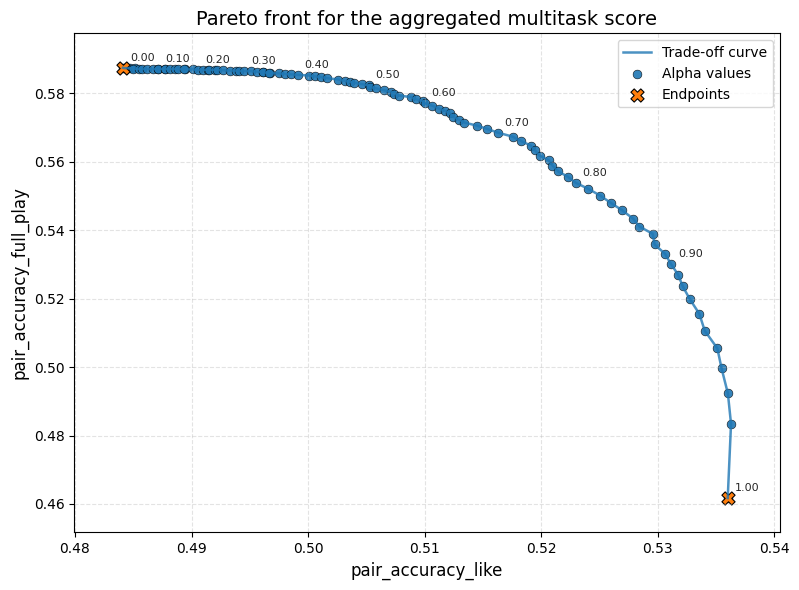

In [40]:
preds = collect_multitask_predictions(
    model=model_multitask_dcnv2_mlp,
    test_loader=test_loader,
    device=device,
)

pareto_front = build_pareto_front(preds, n_points=101)
plot_pareto_front(pareto_front, annotate_every=10)

## Select the Final Score

Now you need to choose such a value of $\alpha$ for which the final score satisfies the constraints in the test.

Recall that the final score is constructed as

$$
s = \alpha \cdot P(\text{like}) + (1 - \alpha) \cdot P(\text{full_play}).
$$

This can be viewed as choosing the final product trade-off: how much the system is willing to trade quality on likes for quality on full listens. In a real task, this is exactly the kind of choice that has to be made when building the final ranking.

In this task, you need to:
1. choose a value of $\alpha$;
2. compute the final score with this weight;
3. make sure that it satisfies the constraints from the test.

In [41]:
alpha = 0.8

#####################
### (づ•̀ᴗ•́)づ──☆*:・ﾟ
#####################

final_score = (
    alpha * preds["like_probs"]
    + (1.0 - alpha) * preds["full_play_probs"]
)

metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=preds["uids"],
        timestamps=preds["timestamps"],
        labels=preds["like_labels"],
        probs=final_score,
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=preds["uids"],
        timestamps=preds["timestamps"],
        labels=preds["full_play_labels"],
        probs=final_score,
    ),
}

tests.test_model_multitask_dcnv2_mlp_combined_score_metrics(metrics)

All good! :)


**Conclusion:** an aggregation weight of α = 0.8 produced the best overall compromise between the two objectives. With this value, the final combined score achieved strong performance which allowed us to pass the test and remain above the random and popularity-based baselines. This suggests that placing a higher weight on the like head leads to the most effective balanced ranking in this setup. It seems to be a more informative signal.